In [2]:
import xarray as xr
ds = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex7_5_onestep_l1_nofc_aheadtop_5_addprecipnorm/prcp_downs_unet_year_2020.nc")
ds

<xarray.Dataset>
Dimensions:    (time: 6912, lat_in: 16, lon_in: 16, lat: 160, lon: 160,
                pitch_idx: 6912)
Coordinates:
  * time       (time) datetime64[ns] 2020-02-01T06:00:00 ... 2020-12-01T02:00:00
  * pitch_idx  (pitch_idx) int32 1 2 3 4 5 6 7 ... 6907 6908 6909 6910 6911 6912
Dimensions without coordinates: lat_in, lon_in, lat, lon
Data variables:
    inputs     (time, lat_in, lon_in) float32 ...
    inter      (time, lat, lon) float32 ...
    fcst       (time, lat, lon) float32 ...
    hr         (time, lat, lon) float32 ...
    lats       (time, lat) float32 ...
    lons       (time, lon) float32 ...
    tops       (time, lat, lon) float32 ...
Attributes:
    description:  Precipitation downscaling data.

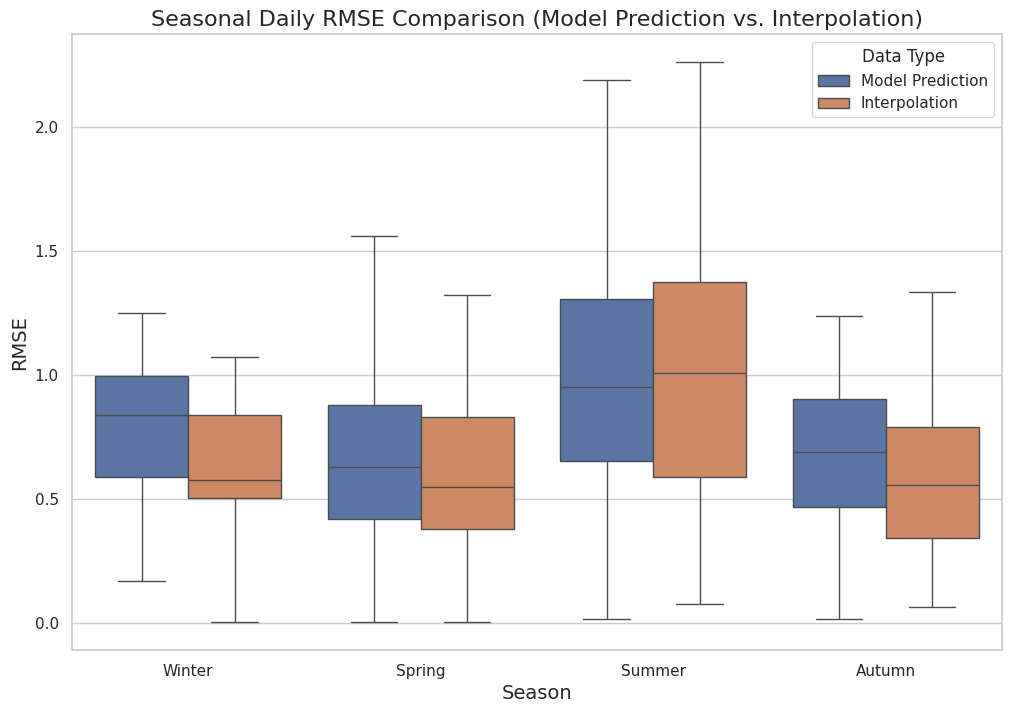

In [29]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 加载数据集
ds = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex7_8_onestep_l1_nofc_aheadtop_005_addprecipnorm/prcp_downs_unet_year_2020.nc")

# 提取变量
fcst = ds['fcst']  # 模型预测结果
hr = ds['hr']      # 高分辨率雷达观测
inter = ds['inter']  # 双三线插值结果
time = pd.to_datetime(ds['time'].values)  # 时间坐标

# 计算按天 RMSE 函数
def calculate_daily_rmse(pred, obs):
    daily_rmse = []
    pred_grouped = pred.groupby('time.date')
    obs_grouped = obs.groupby('time.date')

    for day in pred_grouped.groups:
        pred_data = pred_grouped[day].values.reshape(-1)
        obs_data = obs_grouped[day].values.reshape(-1)
        
        # 计算 RMSE，避免无效数据
        if np.all(np.isnan(pred_data)) or np.all(np.isnan(obs_data)):
            continue
        
        rmse = np.sqrt(np.mean((pred_data - obs_data) ** 2))
        daily_rmse.append({'date': day, 'rmse': rmse})
    
    return pd.DataFrame(daily_rmse)

# 计算 fcst 和 inter 相对于 hr 的 RMSE
df_fcst = calculate_daily_rmse(fcst, hr)
df_inter = calculate_daily_rmse(inter, hr)

# 添加模型类型
df_fcst['Type'] = 'Model Prediction'
df_inter['Type'] = 'Interpolation'
df = pd.concat([df_fcst, df_inter])

# 将日期转换为 datetime 格式
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.month

# 季节映射
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

df['season'] = df['month'].map(get_season)

# 设置绘图风格
sns.set(style="whitegrid")

# 绘制箱线图，禁用离群点
plt.figure(figsize=(12, 8))
sns.boxplot(x='season', y='rmse', hue='Type', data=df,
            order=['Winter', 'Spring', 'Summer', 'Autumn'],
            showfliers=False)  # 不显示离群点

# 美化图表
plt.title('Seasonal Daily RMSE Comparison (Model Prediction vs. Interpolation)', fontsize=16)
plt.xlabel('Season', fontsize=14)
plt.ylabel('RMSE', fontsize=14)
plt.legend(title='Data Type', loc='upper right')

plt.show()


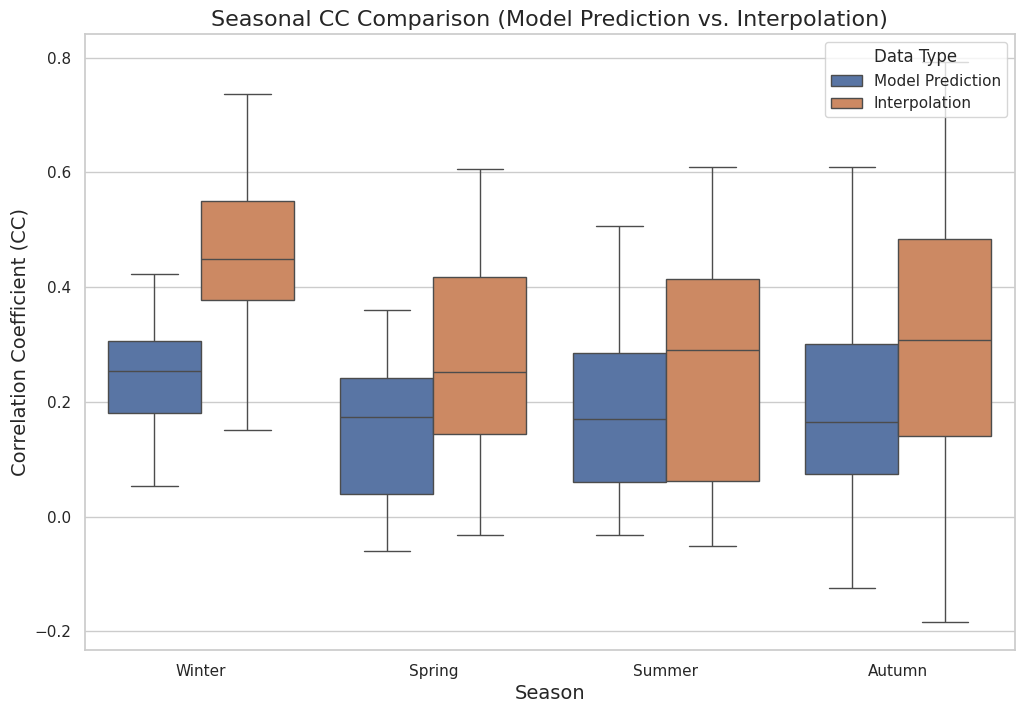

In [33]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 加载数据集
ds = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex7_8_onestep_l1_nofc_aheadtop_005_addprecipnorm/prcp_downs_unet_year_2020.nc")

# 提取变量
fcst = ds['fcst']  # 模型预测结果
hr = ds['hr']      # 高分辨率雷达观测
inter = ds['inter']  # 双三线插值结果
time = pd.to_datetime(ds['time'].values)  # 时间坐标

# 计算每天的相关系数
def calculate_daily_cc(pred, obs):
    daily_cc = []
    
    # 使用groupby分组
    pred_grouped = pred.groupby('time.date')
    obs_grouped = obs.groupby('time.date')

    for day in pred_grouped.groups:
        # 直接迭代获取分组数据
        pred_data = pred_grouped[day]
        obs_data = obs_grouped[day]

        # 展平数据
        pred_flat = pred_data.values.reshape(-1)
        obs_flat = obs_data.values.reshape(-1)
        
        # 处理除零情况，避免NaN
        if np.std(pred_flat) == 0 or np.std(obs_flat) == 0:
            continue  # 跳过标准差为零的情况
        
        # 计算相关系数
        cc = np.corrcoef(pred_flat, obs_flat)[0, 1]
        
        daily_cc.append({'date': day, 'cc': cc})
    
    return pd.DataFrame(daily_cc)

# 计算 fcst 和 inter 相对于 hr 的 CC
df_fcst = calculate_daily_cc(fcst, hr)
df_inter = calculate_daily_cc(inter, hr)

# 合并数据，添加模型类型
df_fcst['Type'] = 'Model Prediction'
df_inter['Type'] = 'Interpolation'
df = pd.concat([df_fcst, df_inter])

# 去除重复索引
df = df.drop_duplicates(subset=['date', 'Type'])

# 将日期转换为 datetime 格式，提取月份和季节
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.month

# 季节映射
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

df['season'] = df['month'].map(get_season)

# 设置绘图风格
sns.set(style="whitegrid")

# 绘制箱线图，禁用离群点
plt.figure(figsize=(12, 8))
sns.boxplot(x='season', y='cc', hue='Type', data=df,
            order=['Winter', 'Spring', 'Summer', 'Autumn'],
            showfliers=False)  # 不显示离群点

# 美化图表
plt.title('Seasonal CC Comparison (Model Prediction vs. Interpolation)', fontsize=16)
plt.xlabel('Season', fontsize=14)
plt.ylabel('Correlation Coefficient (CC)', fontsize=14)
plt.legend(title='Data Type', loc='upper right')

plt.show()


In [6]:
import numpy as np

ds = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex7_4_onestep_l1_nofc_aheadtop_10/prcp_downs_unet_year_2020.nc")

inter = ds['inter'].values  # 模型预测结果
hr = ds['hr'].values      # 高分辨率观测数据

# 计算RMSE
rmse = np.sqrt(np.mean((inter - hr) ** 2))

# 计算相关系数（CC）
cc = np.corrcoef(inter.flatten(), hr.flatten())[0, 1]

print(f"RMSE: {rmse:.4f}")
print(f"Correlation Coefficient (CC): {cc:.4f}")


RMSE: 0.9042
Correlation Coefficient (CC): 0.4766


In [13]:
import xarray as xr
import numpy as np

# 加载数据
ds = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex7_4_onestep_l1_nofc_aheadtop_10/prcp_downs_unet_year_2020.nc") 

# 计算 Individual Prediction RMSE
mse_individual = ((ds['inter'] - ds['hr']) ** 2).mean(dim=['lat', 'lon'])  # 空间均方误差
rmse_individual = np.sqrt(mse_individual.mean())  # 时间维度平均并开方

# 计算 Ensemble-Mean RMSE
ensemble_mean = ds['inter'].mean(dim='time')  # 集合平均
mse_ensemble_mean = ((ensemble_mean - ds['hr']) ** 2).mean(dim=['lat', 'lon'])  # 空间均方误差
rmse_ensemble_mean = np.sqrt(mse_ensemble_mean.mean())  # 时间维度平均并开方

# 计算相关系数 CC
def calculate_correlation(fcst, hr):
    fcst_mean = fcst.mean(dim=['lat', 'lon'])  # 预测均值
    hr_mean = hr.mean(dim=['lat', 'lon'])      # 真实值均值

    numerator = ((fcst - fcst_mean) * (hr - hr_mean)).sum(dim=['lat', 'lon'])  # 协方差部分
    denominator = np.sqrt(
        ((fcst - fcst_mean) ** 2).sum(dim=['lat', 'lon']) *
        ((hr - hr_mean) ** 2).sum(dim=['lat', 'lon'])
    )  # 标准差乘积

    cc = (numerator / denominator).mean()  # 计算时间平均 CC
    return cc

# 计算并输出 CC
cc_score = calculate_correlation(ds['inter'], ds['hr'])

# 输出结果
print(f"Individual Prediction RMSE (Mean): {rmse_individual.values:.4f}")
print(f"Ensemble-Mean RMSE: {rmse_ensemble_mean.values:.4f}")
print(f"Correlation Coefficient (CC): {cc_score.values:.4f}")


Individual Prediction RMSE (Mean): 0.9042
Ensemble-Mean RMSE: 0.9848
Correlation Coefficient (CC): 0.2073


In [3]:
import numpy as np

ds = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex7_4_onestep_l1_nofc_aheadtop_10/prcp_downs_unet_year_2020.nc")

fcst = ds['fcst'].values  # 模型预测结果
hr = ds['hr'].values      # 高分辨率观测数据

# 计算RMSE
rmse = np.sqrt(np.mean((fcst - hr) ** 2))

# 计算相关系数（CC）
cc = np.corrcoef(fcst.flatten(), hr.flatten())[0, 1]

print(f"RMSE: {rmse:.4f}")
print(f"Correlation Coefficient (CC): {cc:.4f}")


RMSE: 0.9987
Correlation Coefficient (CC): 0.2891


In [17]:
import xarray as xr
import numpy as np

# 加载数据
ds = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex7_4_onestep_l1_nofc_aheadtop_10/prcp_downs_unet_year_2020.nc") 

# 计算 Individual Prediction RMSE
mse_individual = ((ds['fcst'] - ds['hr']) ** 2).mean(dim=['lat', 'lon'])  # 空间均方误差
rmse_individual = np.sqrt(mse_individual.mean())  # 时间维度平均并开方

# 计算 Ensemble-Mean RMSE
ensemble_mean = ds['fcst'].mean(dim='time')  # 集合平均
mse_ensemble_mean = ((ensemble_mean - ds['hr']) ** 2).mean(dim=['lat', 'lon'])  # 空间均方误差
rmse_ensemble_mean = np.sqrt(mse_ensemble_mean.mean())  # 时间维度平均并开方

# 计算相关系数 CC
def calculate_correlation(fcst, hr):
    fcst_mean = fcst.mean(dim=['lat', 'lon'])  # 预测均值
    hr_mean = hr.mean(dim=['lat', 'lon'])      # 真实值均值

    numerator = ((fcst - fcst_mean) * (hr - hr_mean)).sum(dim=['lat', 'lon'])  # 协方差部分
    denominator = np.sqrt(
        ((fcst - fcst_mean) ** 2).sum(dim=['lat', 'lon']) *
        ((hr - hr_mean) ** 2).sum(dim=['lat', 'lon'])
    )  # 标准差乘积

    cc = (numerator / denominator).mean()  # 计算时间平均 CC
    return cc

# 计算并输出 CC
cc_score = calculate_correlation(ds['fcst'], ds['hr'])

# 输出结果
print(f"Individual Prediction RMSE (Mean): {rmse_individual.values:.4f}")
print(f"Ensemble-Mean RMSE: {rmse_ensemble_mean.values:.4f}")
print(f"Correlation Coefficient (CC): {cc_score.values:.4f}")


Individual Prediction RMSE (Mean): 0.9987
Ensemble-Mean RMSE: 1.0102
Correlation Coefficient (CC): 0.1434


In [4]:
import numpy as np

ds = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex7_5_onestep_l1_nofc_aheadtop_5_addprecipnorm/prcp_downs_unet_year_2020.nc")

fcst = ds['fcst'].values  # 模型预测结果
hr = ds['hr'].values      # 高分辨率观测数据

# 计算RMSE
rmse = np.sqrt(np.mean((fcst - hr) ** 2))

# 计算相关系数（CC）
cc = np.corrcoef(fcst.flatten(), hr.flatten())[0, 1]

print(f"RMSE: {rmse:.4f}")
print(f"Correlation Coefficient (CC): {cc:.4f}")


RMSE: 1.6938
Correlation Coefficient (CC): 0.2512


In [15]:
import xarray as xr
import numpy as np

# 加载数据
ds = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex7_5_onestep_l1_nofc_aheadtop_5_addprecipnorm/prcp_downs_unet_year_2020.nc") 

# 计算 Individual Prediction RMSE
mse_individual = ((ds['fcst'] - ds['hr']) ** 2).mean(dim=['lat', 'lon'])  # 空间均方误差
rmse_individual = np.sqrt(mse_individual.mean())  # 时间维度平均并开方

# 计算 Ensemble-Mean RMSE
ensemble_mean = ds['fcst'].mean(dim='time')  # 集合平均
mse_ensemble_mean = ((ensemble_mean - ds['hr']) ** 2).mean(dim=['lat', 'lon'])  # 空间均方误差
rmse_ensemble_mean = np.sqrt(mse_ensemble_mean.mean())  # 时间维度平均并开方

# 计算相关系数 CC
def calculate_correlation(fcst, hr):
    fcst_mean = fcst.mean(dim=['lat', 'lon'])  # 预测均值
    hr_mean = hr.mean(dim=['lat', 'lon'])      # 真实值均值

    numerator = ((fcst - fcst_mean) * (hr - hr_mean)).sum(dim=['lat', 'lon'])  # 协方差部分
    denominator = np.sqrt(
        ((fcst - fcst_mean) ** 2).sum(dim=['lat', 'lon']) *
        ((hr - hr_mean) ** 2).sum(dim=['lat', 'lon'])
    )  # 标准差乘积

    cc = (numerator / denominator).mean()  # 计算时间平均 CC
    return cc

# 计算并输出 CC
cc_score = calculate_correlation(ds['fcst'], ds['hr'])

# 输出结果
print(f"Individual Prediction RMSE (Mean): {rmse_individual.values:.4f}")
print(f"Ensemble-Mean RMSE: {rmse_ensemble_mean.values:.4f}")
print(f"Correlation Coefficient (CC): {cc_score.values:.4f}")


Individual Prediction RMSE (Mean): 1.6938
Ensemble-Mean RMSE: 1.7033
Correlation Coefficient (CC): 0.1360


In [5]:
import numpy as np

ds = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex7_6_onestep_l1_nofc_aheadtop_10_addprecipnorm/prcp_downs_unet_year_2020.nc")

fcst = ds['fcst'].values  # 模型预测结果
hr = ds['hr'].values      # 高分辨率观测数据

# 计算RMSE
rmse = np.sqrt(np.mean((fcst - hr) ** 2))

# 计算相关系数（CC）
cc = np.corrcoef(fcst.flatten(), hr.flatten())[0, 1]

print(f"RMSE: {rmse:.4f}")
print(f"Correlation Coefficient (CC): {cc:.4f}")


RMSE: 1.5652
Correlation Coefficient (CC): 0.2734
